# Phase 2: lifestyle profile, root causes and personal routines

Phase 1 split 5 million employees into six groups. Phase 2 moves from "who has a problem" to "why, and what can
each person change". This notebook does the data work behind the [Phase 2 report](PHASE2_REPORT.md):

| Part | Content |
|---|---|
| A | Lifestyle survey of the six groups (from the 5M records), compared with official health guidelines |
| B | What the data can and cannot say about root causes |
| C | Model-based estimate of the benefit of each routine change, per group |
| D | Figures for the root-cause (fishbone) analysis and the daily routines |

**Important.** Nobody was surveyed for this project. "Survey" here means a structured look at the existing
records. A questionnaire for a real follow-up survey is in [survey_questionnaire.md](survey_questionnaire.md).
The data is synthetic, so all numbers illustrate the method.

## 0. Setup

In [1]:
import json
import sys
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Rectangle
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from config import CLUSTER_FEATURES, LABELS, OUTCOMES, PROCESSED, REPORTS
import plotting as P

P.setup_style()
FIG = ROOT / "phase2" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
save = lambda fig, name: fig.savefig(FIG / f"{name}.png", bbox_inches="tight", pad_inches=0.25)  # noqa: E731
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
short = lambda c: LABELS.get(c, c).split(" (")[0]  # noqa: E731
RED_SEQ = LinearSegmentedColormap.from_list("red_seq", ["#ffffff", "#fbe3e2", "#f3aeac", "#e5605e", "#b8322f"])

In [2]:
df = pd.read_parquet(PROCESSED / "employees.parquet")
seg = pd.read_parquet(PROCESSED / "segment_assignment.parquet")
assert (seg["user_id"].to_numpy() == df["user_id"].to_numpy()).all()
meta = json.loads((REPORTS / "segment_meta.json").read_text(encoding="utf-8"))
code_of = {s["segment_id"]: s["code"] for s in meta["segments"]}
name_of = {s["code"]: s["name"] for s in meta["segments"]}
level_of = {s["code"]: s["level"] for s in meta["segments"]}
CODES = [s["code"] for s in meta["segments"]]
df["group"] = pd.Categorical(seg["segment_id"].map(code_of), categories=CODES, ordered=True)
df[CLUSTER_FEATURES] = df[CLUSTER_FEATURES].fillna(df[CLUSTER_FEATURES].median())
print(f"{len(df):,} employees in {len(CODES)} groups")
pd.DataFrame({"name": name_of, "risk level": level_of}).rename_axis("code")

5,000,000 employees in 6 groups


,name,risk level
code,,
N1,Low focus + mental strain,Very high
N2,Heavy device use,High
N3,Low focus + low mental strain,High
N4,Mental strain + strong focus,High
N5,Light device use,Low
N6,Strong focus + low mental strain,Low


## A. Lifestyle survey of the six groups

### A1. Daily-life profile
Averages for each group. The last column is the all-employee average.

In [3]:
LIFESTYLE = ["sleep_hours", "sleep_quality", "caffeine_intake", "physical_activity", "stress_level",
             "daily_screen_time", "social_media_hours", "doomscrolling_duration", "notification_count",
             "smartphone_unlocks", "late_night_device_usage", "deep_work_hours", "focus_sessions",
             "distraction_frequency", "meeting_hours", "remote_work_days"]
prof = df.groupby("group", observed=True)[LIFESTYLE].mean().T
prof["All"] = df[LIFESTYLE].mean()
prof.index = [LABELS[c] for c in prof.index]
prof

group,N1,N2,N3,N4,N5,N6,All
Sleep (h/night),6.50,6.50,6.50,6.50,6.50,6.50,6.50
Sleep quality (1-10),5.50,5.50,5.50,5.50,5.51,5.50,5.50
"Caffeine intake (per day, unit not stated)",3.50,3.50,3.50,3.50,3.50,3.50,3.50
Physical activity (h/day),1.24,1.24,1.24,1.24,1.24,1.24,1.24
Stress (1-10),5.50,5.50,5.49,5.50,5.50,5.51,5.50
Screen time (h/day),8.00,8.98,8.00,8.00,7.01,8.00,8.00
Social media (h/day),3.52,4.21,3.51,3.51,2.84,3.51,3.52
Doomscrolling (h/day),1.83,2.29,1.83,1.83,1.40,1.83,1.83
Notifications per day,209.63,253.21,209.25,209.47,165.39,209.38,209.44
Phone unlocks per day,157.03,189.78,157.11,156.88,124.00,157.23,157.04


### A2. What differs between groups, and what does not
Difference from the all-employee average in standard deviations (SD). Red = more of a problem, blue = less.

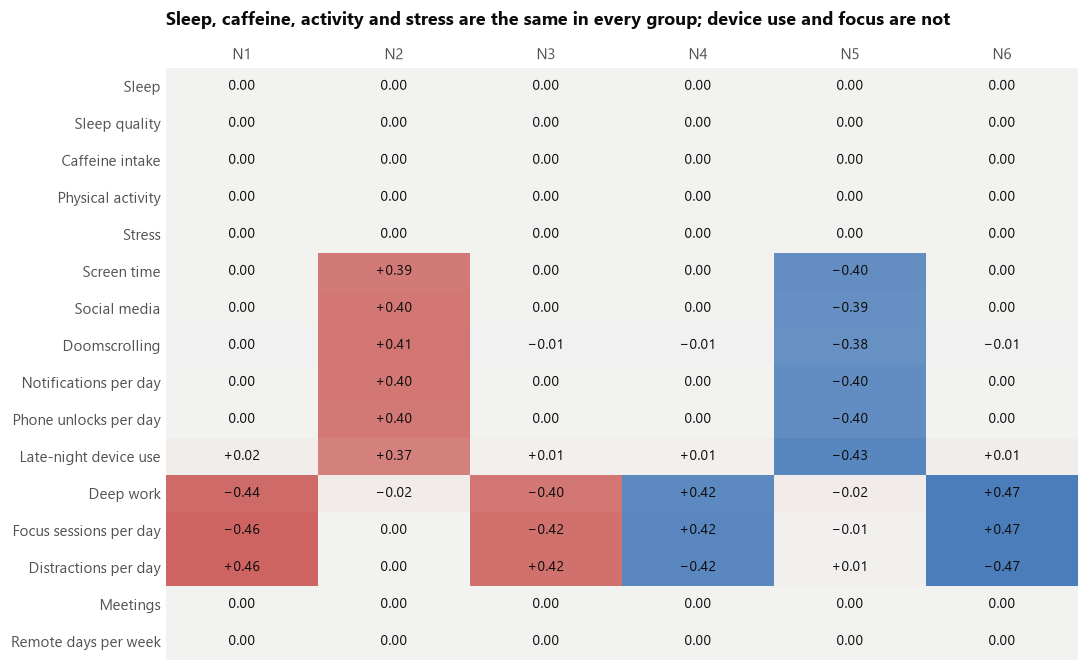

In [4]:
PROBLEM_DIR = {"sleep_hours": -1, "sleep_quality": -1, "caffeine_intake": +1, "physical_activity": -1, "stress_level": +1,
               "daily_screen_time": +1, "social_media_hours": +1, "doomscrolling_duration": +1, "notification_count": +1,
               "smartphone_unlocks": +1, "late_night_device_usage": +1, "deep_work_hours": -1, "focus_sessions": -1,
               "distraction_frequency": +1, "meeting_hours": 0, "remote_work_days": 0}
z = (df.groupby("group", observed=True)[LIFESTYLE].mean() - df[LIFESTYLE].mean()) / df[LIFESTYLE].std()
zp = z.mul(pd.Series(PROBLEM_DIR)).T  # neutral columns become 0
zraw = z.T
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.imshow(zp.to_numpy(), cmap=P.DIVERGING, vmin=-0.6, vmax=0.6, aspect="auto")
ax.set_xticks(range(len(CODES)), CODES)
ax.set_yticks(range(len(LIFESTYLE)), [short(c) for c in LIFESTYLE])
ax.xaxis.tick_top()
for i, c in enumerate(LIFESTYLE):
    for j, g in enumerate(CODES):
        v = zraw.loc[c, g]
        ax.text(j, i, P.num(v, 2, signed=True), ha="center", va="center", fontsize=9,
                color=P.text_on(P.cmap_hex(P.DIVERGING, (zp.loc[c, g] + 0.6) / 1.2)))
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title("Sleep, caffeine, activity and stress are the same in every group; device use and focus are not",
             fontsize=11.5, pad=28)
fig.tight_layout()
save(fig, "p2_01_what_differs")
plt.show()

### A3. How many people meet official guidelines?

| Check | Guideline | Source |
|---|---|---|
| Sleep under 7 h | Adults should sleep 7 or more hours a night | AASM & SRS consensus (Watson et al., 2015) |
| Sleep 6 h or less | 6 hours or less is inadequate for health | same |
| Late-night device use | Turn devices off at least 30 minutes before bed | CDC sleep tips |
| Physical activity under 150 min/week | 150–300 minutes of moderate activity a week | WHO 2020 guidelines |
| Social media over 30 min/day | Limiting use to about 30 min/day improved wellbeing in a trial | Hunt et al., 2018 |
| Stress 8+ | Warning-sign threshold from Phase 1 | this project |

Physical activity is recorded in hours per day, so 150 min/week is taken as 150 / 7 / 60 ≈ 0.36 h/day.
The caffeine column has no stated unit, so it is described but not checked against the FDA's 400 mg guide.

group,N1,N2,N3,N4,N5,N6,All
Sleep under 7 h,62.50,62.60,62.50,62.60,62.40,62.50,62.50
Sleep 6 h or less,37.40,37.40,37.40,37.40,37.30,37.40,37.40
Late-night device use,65.70,82.80,65.60,65.60,44.50,65.70,65.00
Physical activity under 150 min/week,17.30,17.30,17.20,17.30,17.10,17.20,17.20
Social media over 30 min/day,95.30,98.20,95.30,95.30,90.70,95.30,95.00
Screen time over 10 h/day,20.20,32.80,20.20,20.20,10.20,20.10,20.60
Deep work under 2 h/day,43.50,26.30,41.60,14.00,26.40,12.80,27.40
Stress 8+,30.00,30.00,29.90,30.10,29.90,30.00,30.00


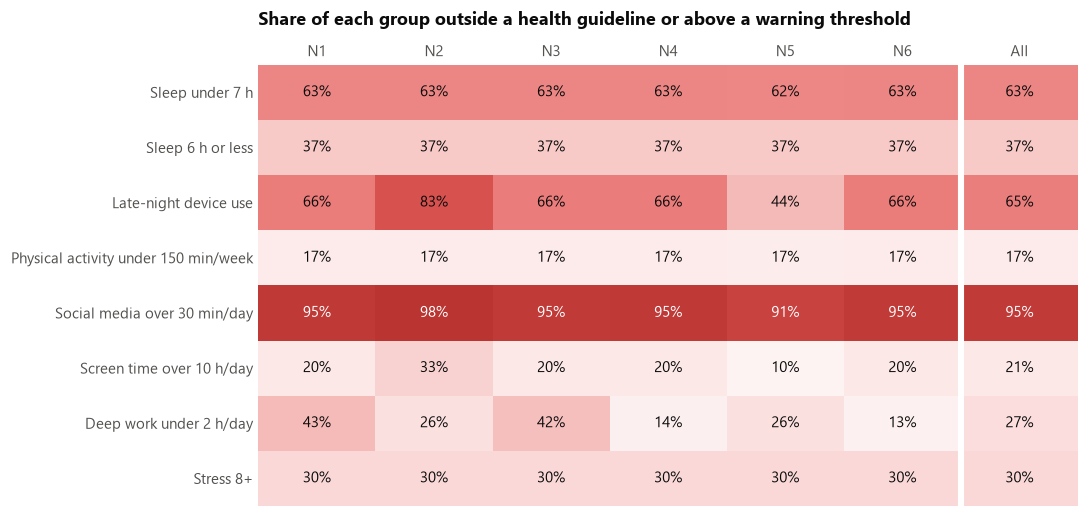

In [5]:
CHECKS = {
    "Sleep under 7 h": df["sleep_hours"] < 7,
    "Sleep 6 h or less": df["sleep_hours"] <= 6,
    "Late-night device use": df["late_night_device_usage"] == 1,
    "Physical activity under 150 min/week": df["physical_activity"] < 150 / 7 / 60,
    "Social media over 30 min/day": df["social_media_hours"] > 0.5,
    "Screen time over 10 h/day": df["daily_screen_time"] > 10,
    "Deep work under 2 h/day": df["deep_work_hours"] < 2,
    "Stress 8+": df["stress_level"] >= 8,
}
gaps = pd.DataFrame({k: v.groupby(df["group"], observed=True).mean() * 100 for k, v in CHECKS.items()}).T
gaps["All"] = [v.mean() * 100 for v in CHECKS.values()]
display(gaps.round(1))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.imshow(gaps.to_numpy(), cmap=RED_SEQ, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(gaps.shape[1]), gaps.columns)
ax.set_yticks(range(gaps.shape[0]), gaps.index)
ax.xaxis.tick_top()
for i in range(gaps.shape[0]):
    for j in range(gaps.shape[1]):
        v = gaps.iat[i, j]
        ax.text(j, i, P.num(v, 0, suffix="%"), ha="center", va="center", fontsize=9.5,
                color=P.text_on(P.cmap_hex(RED_SEQ, v / 100)))
ax.axvline(gaps.shape[1] - 1.5, color=P.SURFACE, lw=4)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_title("Share of each group outside a health guideline or above a warning threshold", fontsize=12, pad=26)
fig.tight_layout()
save(fig, "p2_02_guideline_gaps")
plt.show()

**What the lifestyle survey shows**
- **Shared by everyone:** about 63% sleep under 7 hours and 37% sleep 6 hours or less; about 17% do less than
  150 minutes of activity a week; about 30% report stress of 8 or more. These rates are the same in every group.
- **Different between groups:** device use (N2 highest, N5 lowest), focus and deep work (N1 and N3 lowest), and
  mental state (N1 and N4 most strained, from Phase 1).
- Almost everyone (91–98%) uses social media for more than 30 minutes a day, and the average is 3.5 hours.
- So routines need two layers: a **shared base** (sleep, activity, stress) for everyone, and a **group layer** for
  the problem that makes each group different.

## B. What the data can and cannot say about root causes

A root-cause chain such as "late-night phone use → shorter sleep → more burnout" needs the middle link to show up in
the data. The table below checks the links between the lifestyle measures themselves.

In [6]:
pairs = [("late_night_device_usage", "sleep_hours"), ("late_night_device_usage", "sleep_quality"),
         ("daily_screen_time", "sleep_quality"), ("caffeine_intake", "sleep_hours"), ("stress_level", "sleep_quality"),
         ("physical_activity", "stress_level"), ("distraction_frequency", "deep_work_hours"),
         ("notification_count", "distraction_frequency"), ("meeting_hours", "deep_work_hours"),
         ("emotional_exhaustion", "motivation_level")]
links = pd.DataFrame([{"from": short(a), "to": short(b), "r": df[a].corr(df[b])} for a, b in pairs])
links

,from,to,r
0,Late-night device use,Sleep,-0.00
1,Late-night device use,Sleep quality,0.00
2,Screen time,Sleep quality,-0.00
3,Caffeine intake,Sleep,0.00
4,Stress,Sleep quality,0.00
5,Physical activity,Stress,-0.00
6,Distractions per day,Deep work,-0.00
7,Notifications per day,Distractions per day,0.00
8,Meetings,Deep work,-0.00
9,Emotional exhaustion,Motivation,-0.00


Every link is close to zero (|r| < 0.01). In real life several of these links are well documented (for example,
evening screen light delays sleep, Chang et al., 2015; caffeine up to 6 hours before bed shortens sleep, Drake et al.,
2013). Their absence here is a property of the synthetic data.

**Consequence for the analysis:** the data can show *which* problems a group has and *how strongly* each measure is
associated with the outcomes. It cannot show *why* a group has them. The root causes in the report are therefore
**hypotheses built from research frameworks**, each tagged as either data-backed (a measured difference) or a
hypothesis to test with the follow-up survey.

## C. Model-based benefit of each routine change

A linear model of each outcome on all 25 measures plus self-reported mental state gives a simple way to compare
changes. Each change is applied to every member of a group, and the model predicts the new group average.
These are **associations in synthetic data, not causal effects**. They are useful for ranking changes, not for
promising results.

In [7]:
X_cols = CLUSTER_FEATURES
Xd = pd.get_dummies(df[X_cols + ["mental_state"]], columns=["mental_state"], drop_first=True, dtype=float)
Xd.insert(0, "const", 1.0)
coef, r2 = {}, {}
for y in OUTCOMES:
    beta, *_ = np.linalg.lstsq(Xd.to_numpy(), df[y].to_numpy(dtype=float), rcond=None)
    coef[y] = pd.Series(beta, index=Xd.columns)
    pred = Xd.to_numpy() @ beta
    r2[y] = 1 - ((df[y] - pred) ** 2).sum() / ((df[y] - df[y].mean()) ** 2).sum()
print({k: round(v, 3) for k, v in r2.items()})
coef_tbl = pd.DataFrame(coef).loc[X_cols]
coef_tbl.index = [LABELS[c] for c in coef_tbl.index]
coef_tbl.rename(columns={"burnout_risk": "burnout points per unit", "productivity_score": "productivity points per unit"}).round(3)

{'burnout_risk': np.float64(0.788), 'productivity_score': np.float64(0.815)}


,burnout points per unit,productivity points per unit
Screen time (h/day),1.95,-0.68
Social media (h/day),-0.00,-1.73
Doomscrolling (h/day),3.90,-1.35
App switches per day,0.00,-0.03
Notifications per day,0.02,-0.01
Phone unlocks per day,0.00,-0.00
Late-night device use (0/1),7.34,-2.54
Focus sessions per day,0.00,1.73
Deep work (h/day),-0.60,6.98
Distractions per day,0.10,-0.03


In [8]:
CHANGES = {
    "Sleep at least 7 h": lambda d: d.assign(sleep_hours=d["sleep_hours"].clip(lower=7)),
    "No late-night device use": lambda d: d.assign(late_night_device_usage=0.0),
    "Doomscrolling at most 30 min": lambda d: d.assign(doomscrolling_duration=d["doomscrolling_duration"].clip(upper=0.5)),
    "Social media at most 30 min": lambda d: d.assign(social_media_hours=d["social_media_hours"].clip(upper=0.5)),
    "Screen time at most 8 h": lambda d: d.assign(daily_screen_time=d["daily_screen_time"].clip(upper=8)),
    "Notifications halved (batching)": lambda d: d.assign(notification_count=d["notification_count"] * 0.5),
    "Activity at least 30 min/day": lambda d: d.assign(physical_activity=d["physical_activity"].clip(lower=0.5)),
    "Stress 1 point lower": lambda d: d.assign(stress_level=(d["stress_level"] - 1).clip(lower=1)),
    "One more hour of deep work": lambda d: d.assign(deep_work_hours=d["deep_work_hours"] + 1),
    "Two more focus sessions": lambda d: d.assign(focus_sessions=(d["focus_sessions"] + 2).clip(upper=9)),
    "Distractions 30% fewer": lambda d: d.assign(distraction_frequency=d["distraction_frequency"] * 0.7),
}

def predict(d, y):
    """Full model prediction (all measures + mental-state dummies + intercept)."""
    Xn = pd.get_dummies(d[X_cols + ["mental_state"]], columns=["mental_state"], drop_first=True, dtype=float)
    Xn.insert(0, "const", 1.0)
    return Xn.reindex(columns=Xd.columns, fill_value=0.0).to_numpy() @ coef[y].to_numpy()

sample = df.groupby("group", observed=True).sample(n=200_000, random_state=42)
rows = []
for g in CODES:
    base = sample[sample["group"] == g]
    for name, fn in CHANGES.items():
        new = fn(base.copy())
        row = {"group": g, "change": name}
        for y in OUTCOMES:
            row[y] = float((predict(new, y) - predict(base, y)).mean())
        rows.append(row)
whatif = pd.DataFrame(rows)
wb = whatif.pivot(index="change", columns="group", values="burnout_risk").loc[list(CHANGES), CODES]
wp = whatif.pivot(index="change", columns="group", values="productivity_score").loc[list(CHANGES), CODES]
print("Change in average burnout risk (points, 0-100 scale):")
display(wb.round(1))
print("Change in average productivity score (points, 0-100 scale):")
wp.round(1)

Change in average burnout risk (points, 0-100 scale):


group,N1,N2,N3,N4,N5,N6
change,,,,,,
Sleep at least 7 h,-1.70,-1.70,-1.70,-1.70,-1.70,-1.70
No late-night device use,-4.80,-6.10,-4.80,-4.80,-3.30,-4.80
Doomscrolling at most 30 min,-5.40,-7.10,-5.40,-5.40,-3.80,-5.40
Social media at most 30 min,0.00,0.00,0.00,0.00,0.00,0.00
Screen time at most 8 h,-1.90,-3.00,-1.90,-1.90,-1.10,-1.90
Notifications halved (batching),-2.00,-2.50,-2.00,-2.00,-1.60,-2.00
Activity at least 30 min/day,-0.20,-0.20,-0.20,-0.20,-0.20,-0.20
Stress 1 point lower,-2.60,-2.60,-2.60,-2.60,-2.60,-2.60
One more hour of deep work,-0.60,-0.60,-0.60,-0.60,-0.60,-0.60


Change in average productivity score (points, 0-100 scale):


group,N1,N2,N3,N4,N5,N6
change,,,,,,
Sleep at least 7 h,0.60,0.60,0.60,0.60,0.60,0.60
No late-night device use,1.70,2.10,1.70,1.70,1.10,1.70
Doomscrolling at most 30 min,1.90,2.50,1.90,1.90,1.30,1.90
Social media at most 30 min,5.20,6.40,5.20,5.20,4.10,5.20
Screen time at most 8 h,0.70,1.00,0.70,0.70,0.40,0.70
Notifications halved (batching),0.70,0.90,0.70,0.70,0.60,0.70
Activity at least 30 min/day,0.10,0.10,0.10,0.10,0.10,0.10
Stress 1 point lower,0.90,0.90,0.90,0.90,0.90,0.90
One more hour of deep work,7.00,7.00,7.00,7.00,7.00,7.00


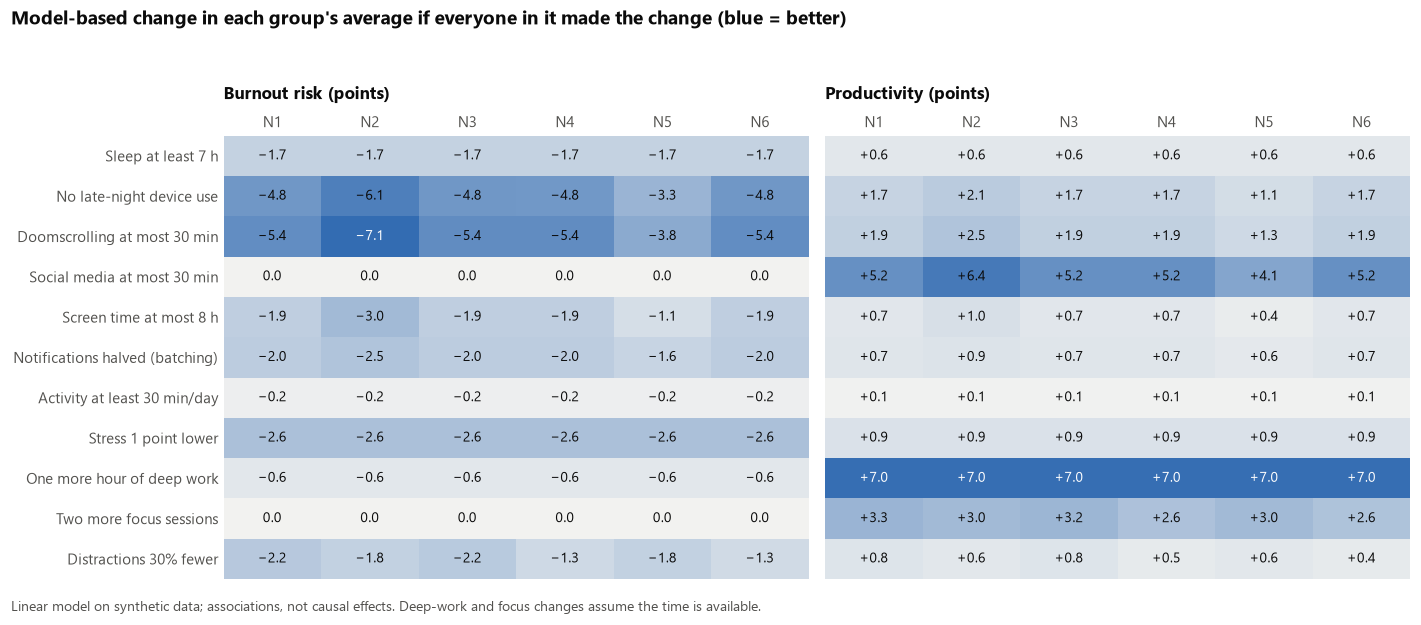

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)
for ax, tbl, title, sign in [(axes[0], wb, "Burnout risk (points)", 1), (axes[1], wp, "Productivity (points)", -1)]:
    ax.imshow((tbl * sign).to_numpy(), cmap=P.DIVERGING, vmin=-8, vmax=8, aspect="auto")
    ax.set_xticks(range(len(CODES)), CODES)
    ax.xaxis.tick_top()
    for i in range(tbl.shape[0]):
        for j in range(tbl.shape[1]):
            v = tbl.iat[i, j]
            ax.text(j, i, P.num(v, 1, signed=True), ha="center", va="center", fontsize=9,
                    color=P.text_on(P.cmap_hex(P.DIVERGING, (v * sign + 8) / 16)))
    ax.set_title(title, fontsize=11, pad=24)
    for sp in ax.spines.values():
        sp.set_visible(False)
axes[0].set_yticks(range(len(CHANGES)), list(CHANGES))
fig.suptitle("Model-based change in each group's average if everyone in it made the change (blue = better)",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold")
fig.text(0.01, 0.005, "Linear model on synthetic data; associations, not causal effects. Deep-work and focus changes assume the time is available.",
         fontsize=9, color=P.INK_2)
fig.tight_layout(rect=(0, 0.03, 1, 0.94))
save(fig, "p2_03_model_benefit")
plt.show()

### C2. Routine bundles per group
Each group gets the shared base (sleep, activity, stress) plus changes aimed at its own problem.

In [10]:
BASE = ["Sleep at least 7 h", "Activity at least 30 min/day", "Stress 1 point lower"]
BUNDLES = {
    "N1": BASE + ["One more hour of deep work", "Distractions 30% fewer", "Two more focus sessions"],
    "N2": BASE + ["No late-night device use", "Doomscrolling at most 30 min", "Social media at most 30 min",
                  "Screen time at most 8 h", "Notifications halved (batching)"],
    "N3": BASE + ["One more hour of deep work", "Distractions 30% fewer", "Two more focus sessions"],
    "N4": BASE + ["No late-night device use"],
    "N5": BASE,
    "N6": BASE,
}
bundle_rows = []
for g, changes in BUNDLES.items():
    d0 = sample[sample["group"] == g]
    d1 = d0.copy()
    for ch in changes:
        d1 = CHANGES[ch](d1)
    pb = np.clip(predict(d1, "burnout_risk"), 0, 100).mean() - np.clip(predict(d0, "burnout_risk"), 0, 100).mean()
    pp = np.clip(predict(d1, "productivity_score"), 0, 100).mean() - np.clip(predict(d0, "productivity_score"), 0, 100).mean()
    s = next(x for x in meta["segments"] if x["code"] == g)
    bundle_rows.append({"group": g, "name": s["name"], "burnout now": s["burnout"], "burnout change": pb,
                        "productivity now": s["productivity"], "productivity change": pp,
                        "changes in bundle": len(changes)})
bundles = pd.DataFrame(bundle_rows).set_index("group")
bundles

,name,burnout now,burnout change,productivity now,productivity change,changes in bundle
group,,,,,,
N1,Low focus + mental strain,58.89,-7.34,49.51,12.57,6
N2,Heavy device use,54.56,-23.02,67.85,13.92,8
N3,Low focus + low mental strain,41.19,-7.27,63.84,12.23,6
N4,Mental strain + strong focus,55.76,-9.34,80.43,2.88,4
N5,Light device use,42.60,-4.53,76.19,1.51,3
N6,Strong focus + low mental strain,38.41,-4.51,90.88,1.13,3


Predictions are clipped to the 0–100 scale, and they assume everyone in the group makes every change in full;
real adherence will be lower, so treat these as upper bounds for comparison.
- The shared base (sleep, activity, stress) is worth about 4.5 burnout points in every group. It is most of the
  gain for N1, N3, N5 and N6, about half of it for N4 (the other half comes from ending late-night device use), and
  a small part for N2, where the device changes carry most of the gain.
- For N1 and N3, most of the productivity gain comes from one more hour of deep work and two more focus sessions,
  which only helps if the time can really be freed up.

## D. Figures for the report

### D1. Fishbone diagrams (root-cause hypotheses)
Causes marked **[data]** are measured differences in this dataset; causes marked **[test]** are hypotheses from
research frameworks, to be checked with the follow-up survey.

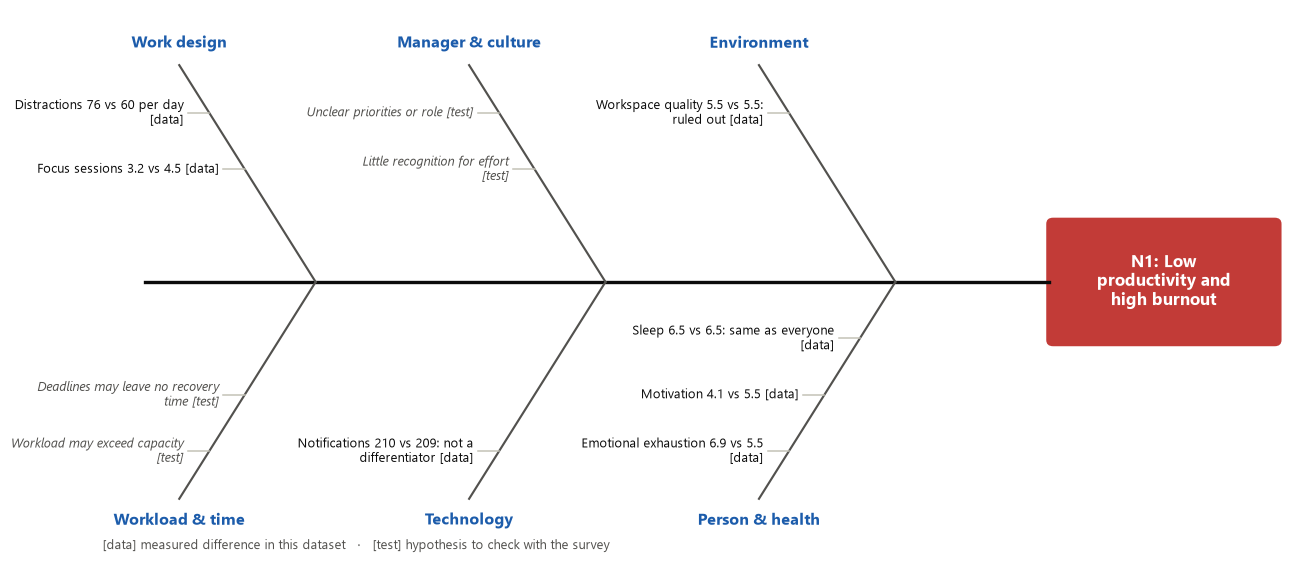

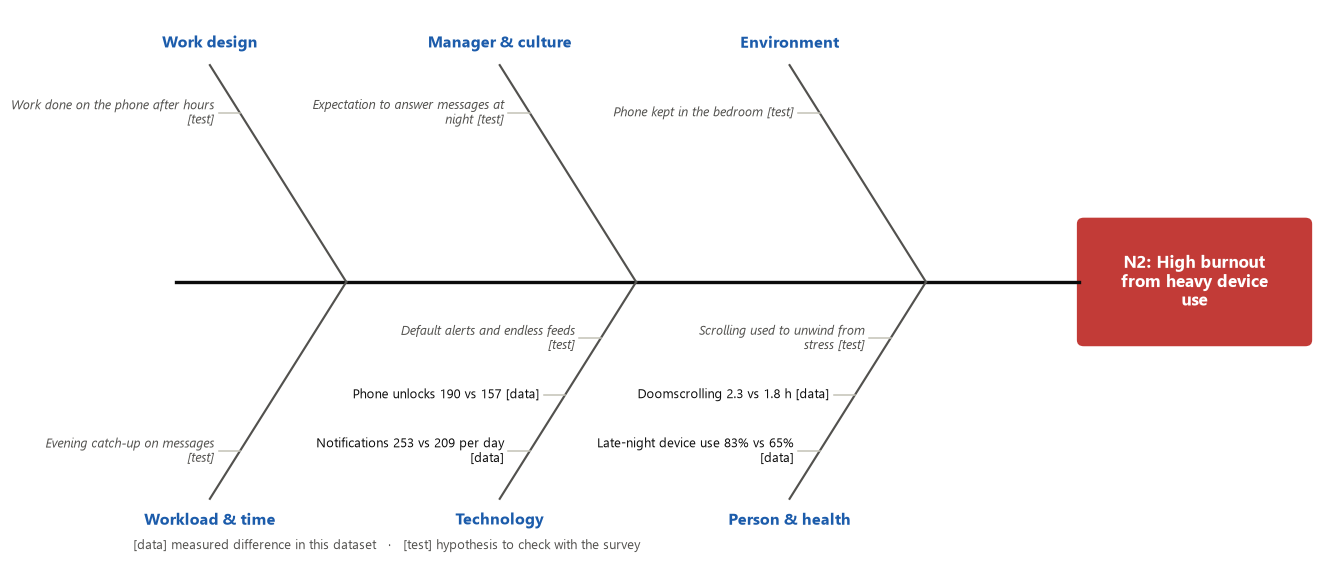

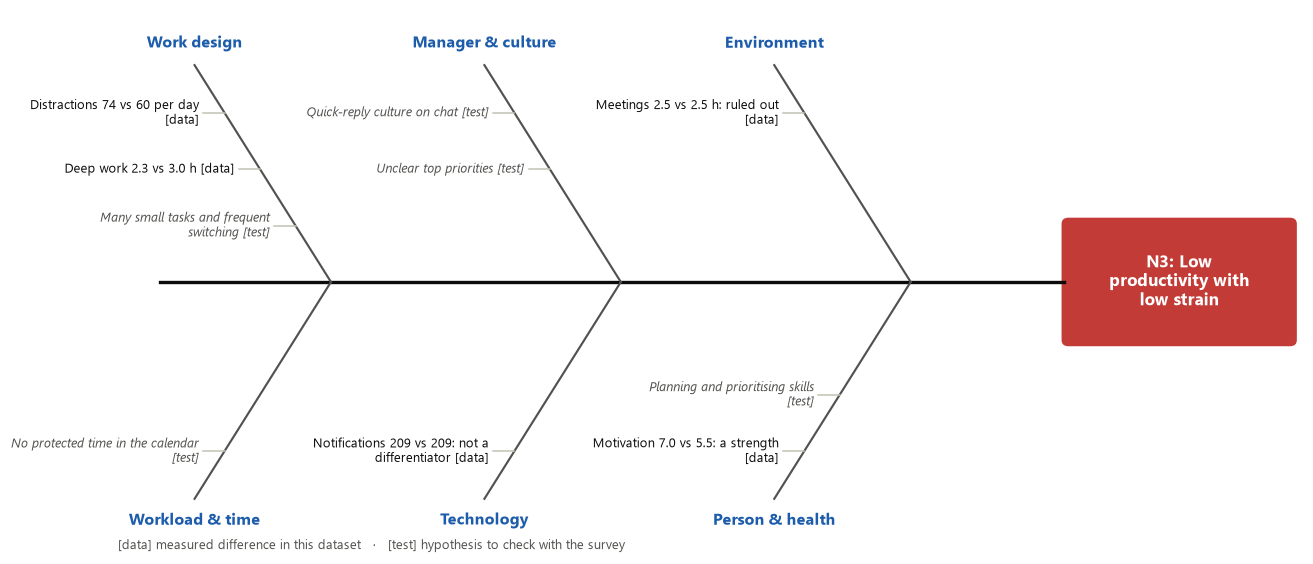

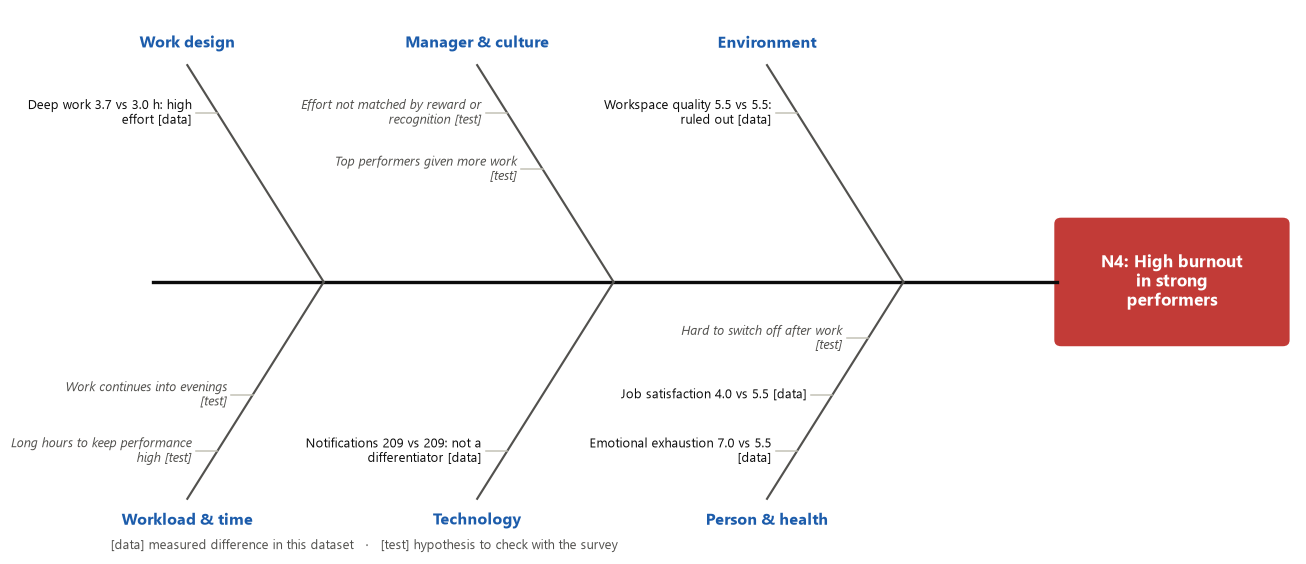

In [11]:
m = df.groupby("group", observed=True)[CLUSTER_FEATURES].mean()
allm = df[CLUSTER_FEATURES].mean()
fmt = lambda g, c, d=1: f"{m.loc[g, c]:.{d}f} vs {allm[c]:.{d}f}"  # noqa: E731

FISHBONES = {
    "N1": ("Low productivity and high burnout", {
        "Work design": [f"Distractions {fmt('N1', 'distraction_frequency', 0)} per day [data]",
                        f"Focus sessions {fmt('N1', 'focus_sessions')} [data]"],
        "Workload & time": ["Workload may exceed capacity [test]", "Deadlines may leave no recovery time [test]"],
        "Manager & culture": ["Unclear priorities or role [test]", "Little recognition for effort [test]"],
        "Technology": [f"Notifications {fmt('N1', 'notification_count', 0)}: not a differentiator [data]"],
        "Environment": [f"Workspace quality {fmt('N1', 'workspace_quality')}: ruled out [data]"],
        "Person & health": [f"Emotional exhaustion {fmt('N1', 'emotional_exhaustion')} [data]",
                            f"Motivation {fmt('N1', 'motivation_level')} [data]",
                            f"Sleep {fmt('N1', 'sleep_hours')}: same as everyone [data]"],
    }),
    "N2": ("High burnout from heavy device use", {
        "Work design": ["Work done on the phone after hours [test]"],
        "Workload & time": ["Evening catch-up on messages [test]"],
        "Manager & culture": ["Expectation to answer messages at night [test]"],
        "Technology": [f"Notifications {fmt('N2', 'notification_count', 0)} per day [data]",
                       f"Phone unlocks {fmt('N2', 'smartphone_unlocks', 0)} [data]",
                       "Default alerts and endless feeds [test]"],
        "Environment": ["Phone kept in the bedroom [test]"],
        "Person & health": [f"Late-night device use {m.loc['N2', 'late_night_device_usage']:.0%} vs {allm['late_night_device_usage']:.0%} [data]",
                            f"Doomscrolling {fmt('N2', 'doomscrolling_duration')} h [data]",
                            "Scrolling used to unwind from stress [test]"],
    }),
    "N3": ("Low productivity with low strain", {
        "Work design": [f"Distractions {fmt('N3', 'distraction_frequency', 0)} per day [data]",
                        f"Deep work {fmt('N3', 'deep_work_hours')} h [data]",
                        "Many small tasks and frequent switching [test]"],
        "Workload & time": ["No protected time in the calendar [test]"],
        "Manager & culture": ["Quick-reply culture on chat [test]", "Unclear top priorities [test]"],
        "Technology": [f"Notifications {fmt('N3', 'notification_count', 0)}: not a differentiator [data]"],
        "Environment": [f"Meetings {fmt('N3', 'meeting_hours')} h: ruled out [data]"],
        "Person & health": [f"Motivation {fmt('N3', 'motivation_level')}: a strength [data]",
                            "Planning and prioritising skills [test]"],
    }),
    "N4": ("High burnout in strong performers", {
        "Work design": [f"Deep work {fmt('N4', 'deep_work_hours')} h: high effort [data]"],
        "Workload & time": ["Long hours to keep performance high [test]", "Work continues into evenings [test]"],
        "Manager & culture": ["Effort not matched by reward or recognition [test]", "Top performers given more work [test]"],
        "Technology": [f"Notifications {fmt('N4', 'notification_count', 0)}: not a differentiator [data]"],
        "Environment": [f"Workspace quality {fmt('N4', 'workspace_quality')}: ruled out [data]"],
        "Person & health": [f"Emotional exhaustion {fmt('N4', 'emotional_exhaustion')} [data]",
                            f"Job satisfaction {fmt('N4', 'work_satisfaction')} [data]",
                            "Hard to switch off after work [test]"],
    }),
}

def draw_fishbone(code, problem, bones):
    fig, ax = plt.subplots(figsize=(14, 6.4))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis("off")
    ax.plot([0.6, 11.2], [3.5, 3.5], color=P.INK, lw=2.2)
    ax.add_patch(FancyBboxPatch((11.25, 2.75), 2.6, 1.5, boxstyle="round,pad=0.08", fc=P.WORSE, ec="none"))
    ax.text(12.55, 3.5, "\n".join(textwrap.wrap(f"{code}: {problem}", 18)), ha="center", va="center",
            color="#ffffff", fontsize=11, fontweight="bold")
    cats = list(bones)
    xs = [2.6, 6.0, 9.4]
    for k, cat in enumerate(cats):
        top = k % 2 == 0
        x_end = xs[k // 2]
        y_tip = 6.3 if top else 0.7
        ax.plot([x_end - 1.6, x_end], [y_tip, 3.5], color=P.INK_2, lw=1.4)
        ax.text(x_end - 1.6, y_tip + (0.28 if top else -0.28), cat, ha="center", va="center", fontsize=10.5,
                fontweight="bold", color=P.BETTER)
        for i, cause in enumerate(bones[cat]):
            frac = 0.22 + i * 0.26
            yy = y_tip + (3.5 - y_tip) * frac
            xx = (x_end - 1.6) + 1.6 * frac
            is_data = cause.endswith("[data]")
            ax.plot([xx - 0.25, xx], [yy, yy], color=P.AXIS, lw=1)
            ax.text(xx - 0.3, yy, "\n".join(textwrap.wrap(cause, 34)), ha="right", va="center", fontsize=8.6,
                    color=P.INK if is_data else P.INK_2, style="normal" if is_data else "italic")
    ax.text(0.1, 0.05, "[data] measured difference in this dataset   ·   [test] hypothesis to check with the survey",
            fontsize=8.8, color=P.INK_2)
    return fig

for code, (problem, bones) in FISHBONES.items():
    fig = draw_fishbone(code, problem, bones)
    save(fig, f"p2_04_fishbone_{code}")
    plt.show()

### D2. Daily routine timelines
One suggested weekday per group. Blue blocks are focused work, red blocks are recovery or limits, grey blocks are
set times for messages. Times are examples; each person shifts them to fit their own schedule.

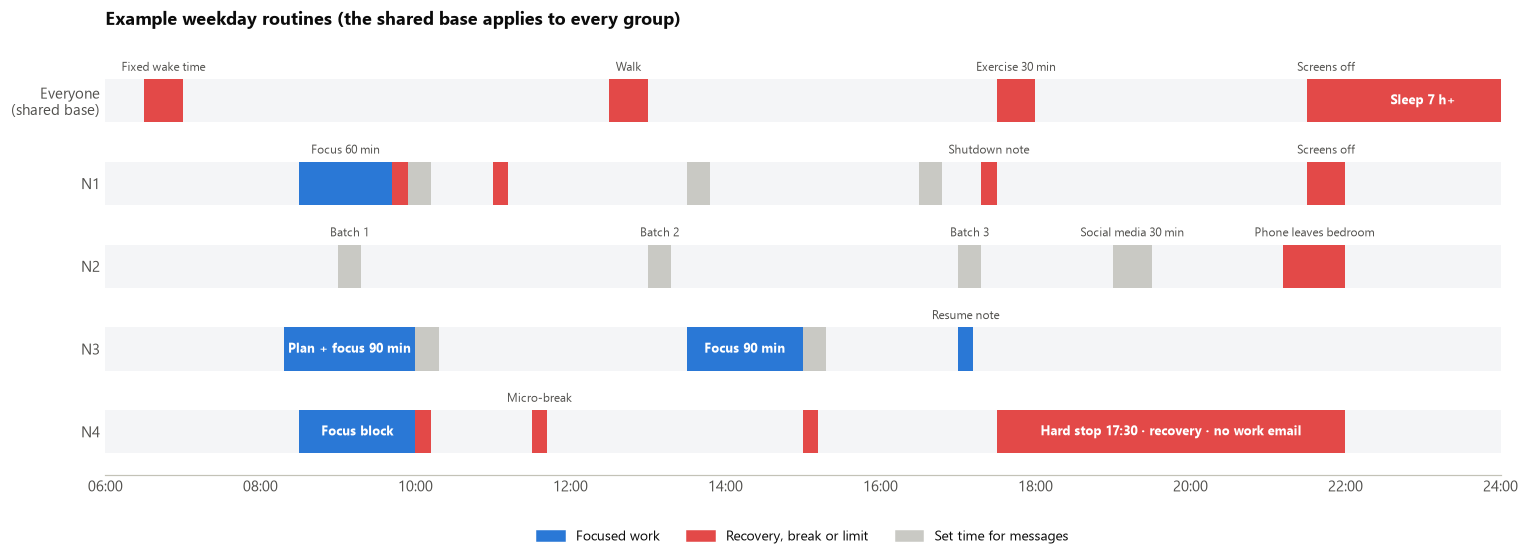

In [12]:
ROUTINES = {  # (start, end, label, kind); labels go inside blocks of 1.2 h or more, above smaller ones
    "Everyone\n(shared base)": [(6.5, 7.0, "Fixed wake time", "rec"), (12.5, 13.0, "Walk", "rec"),
                                (17.5, 18.0, "Exercise 30 min", "rec"), (21.5, 22.0, "Screens off", "rec"),
                                (22.0, 24.0, "Sleep 7 h+", "rec")],
    "N1": [(8.5, 9.7, "Focus 60 min", "work"), (9.7, 9.9, "", "rec"), (9.9, 10.2, "", "msg"), (11.0, 11.2, "", "rec"),
           (13.5, 13.8, "", "msg"), (16.5, 16.8, "", "msg"), (17.3, 17.5, "Shutdown note", "rec"),
           (21.5, 22.0, "Screens off", "rec")],
    "N2": [(9.0, 9.3, "Batch 1", "msg"), (13.0, 13.3, "Batch 2", "msg"), (17.0, 17.3, "Batch 3", "msg"),
           (19.0, 19.5, "Social media 30 min", "msg"), (21.2, 22.0, "Phone leaves bedroom", "rec")],
    "N3": [(8.3, 10.0, "Plan + focus 90 min", "work"), (10.0, 10.3, "", "msg"), (13.5, 15.0, "Focus 90 min", "work"),
           (15.0, 15.3, "", "msg"), (17.0, 17.2, "Resume note", "work")],
    "N4": [(8.5, 10.0, "Focus block", "work"), (10.0, 10.2, "", "rec"), (11.5, 11.7, "Micro-break", "rec"),
           (15.0, 15.2, "", "rec"), (17.5, 22.0, "Hard stop 17:30 · recovery · no work email", "rec")],
}
COL = {"work": P.BLUE, "rec": P.RED, "msg": P.DEEMPH}
fig, ax = plt.subplots(figsize=(14, 5.2))
for r, (who, blocks) in enumerate(ROUTINES.items()):
    y = (len(ROUTINES) - 1 - r) * 1.15
    ax.add_patch(Rectangle((6, y - 0.3), 18, 0.6, color="#f4f5f7", lw=0))
    for s0, s1, lab, kind in blocks:
        ax.add_patch(Rectangle((s0, y - 0.3), s1 - s0, 0.6, color=COL[kind], lw=0))
        if not lab:
            continue
        if s1 - s0 >= 1.2:
            ax.text((s0 + s1) / 2, y, lab, ha="center", va="center", fontsize=8.3, color="#ffffff", fontweight="bold")
        else:
            ax.text((s0 + s1) / 2, y + 0.38, lab, ha="center", va="bottom", fontsize=8, color=P.INK_2)
ax.set_xlim(6, 24)
ax.set_ylim(-0.6, (len(ROUTINES) - 1) * 1.15 + 0.8)
ax.set_yticks([(len(ROUTINES) - 1 - r) * 1.15 for r in range(len(ROUTINES))], list(ROUTINES))
ax.set_xticks(range(6, 25, 2), [f"{h:02d}:00" for h in range(6, 25, 2)])
ax.spines[["left"]].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COL.values()]
ax.legend(handles, ["Focused work", "Recovery, break or limit", "Set time for messages"], loc="upper center",
          bbox_to_anchor=(0.5, -0.1), ncol=3)
ax.set_title("Example weekday routines (the shared base applies to every group)", fontsize=12)
fig.tight_layout()
save(fig, "p2_05_routines")
plt.show()

## E. Export

In [13]:
out = ROOT / "phase2" / "tables"
out.mkdir(exist_ok=True)
prof.round(3).to_csv(out / "a1_lifestyle_profile.csv")
gaps.round(2).to_csv(out / "a3_guideline_gaps.csv")
links.round(4).to_csv(out / "b_lifestyle_links.csv", index=False)
coef_tbl.round(4).to_csv(out / "c_model_coefficients.csv")
wb.round(2).to_csv(out / "c_whatif_burnout.csv")
wp.round(2).to_csv(out / "c_whatif_productivity.csv")
bundles.round(2).to_csv(out / "c_bundles.csv")
for p in sorted(out.iterdir()) + sorted(FIG.iterdir()):
    print(p.relative_to(ROOT))

phase2\tables\a1_lifestyle_profile.csv
phase2\tables\a3_guideline_gaps.csv
phase2\tables\b_lifestyle_links.csv
phase2\tables\c_bundles.csv
phase2\tables\c_model_coefficients.csv
phase2\tables\c_whatif_burnout.csv
phase2\tables\c_whatif_productivity.csv
phase2\figures\p2_01_what_differs.png
phase2\figures\p2_02_guideline_gaps.png
phase2\figures\p2_03_model_benefit.png
phase2\figures\p2_04_fishbone_N1.png
phase2\figures\p2_04_fishbone_N2.png
phase2\figures\p2_04_fishbone_N3.png
phase2\figures\p2_04_fishbone_N4.png
phase2\figures\p2_05_routines.png
